# SMS Spam Classifier:
This project builds a machine learning model that classifies SMS messages as either spam or legitimate (ham). It uses TF-IDF to convert text into numerical features and Multinomial Naive Bayes for classification.

# Technologies Used:
- Python
- Pandas
- Scikit-learn
- Matplotlib
- Jupyter Notebook

# 1. Import Libraries

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix


# 2. Load Dataset:
The dataset contains SMS messages labeled as either "ham" or "spam". The dataset is loaded as a Pandas DataFrame with two colums:
- label
- message

In [59]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"],
)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 3. Explore the Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


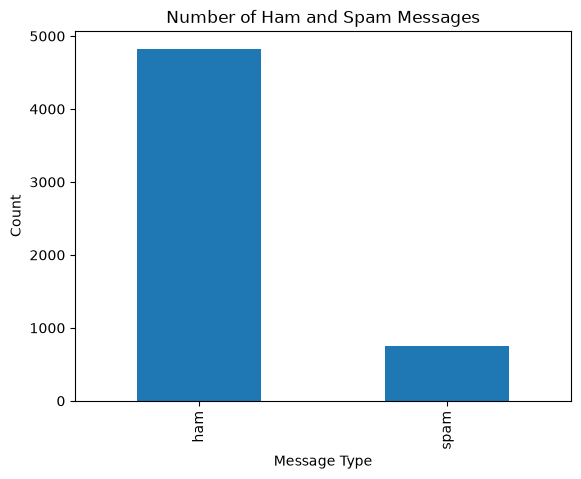

In [60]:
df.info()
df.isnull().sum()
df["label"].value_counts()
df["label"].value_counts().plot(kind="bar")
plt.title("Number of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

# 4. Prepare the Data:
The message column is used as the input feature ('x') and the label column is used as the target ('y'). The labels are converted from text to numerical values:
- '0' -> ham
- '1' -> spam

In [61]:
x = df["message"]
y = df["label"]
y = y.map({"ham": 0, "spam": 1})

# 5. Train-Test Split:
The dataset is divided into training and testing sets. 80% of the data is used for training and 20% is used for testing

In [62]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Convert text to TF-IDF:
TF-IDF (Term Frequency-Inverse Document Frequency) converts the SMS messages into numerical features. The vectorizer is fitted only on the training data and then used to transform the test data. This prevents information from the test set from leaking into the training process.

In [63]:
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)
print(x_train_tfidf.shape)
print(x_test_tfidf.shape)

(4457, 7668)
(1115, 7668)


# 7. Train the Naive Bayes Model:

In [64]:
model = MultinomialNB()
model.fit(x_train_tfidf, y_train)
y_pred = model.predict(x_test_tfidf)

# 8. Model Evaluation:
The model is evaluated using accuracy, precision, recall, and F1-score.

In [65]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9605381165919282
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.70      0.83       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



# Results: 
The model achieved an accuracy of approximately 96%. For spam messages, the model achieved:
- Precision: 1.00
- Recall: 0.70
- F1-score: 0.83
Although the model has high precision, its recall indicates that some spam messages are still being missed.

# 9. Confusion Matrix:

[[966   0]
 [ 44 105]]


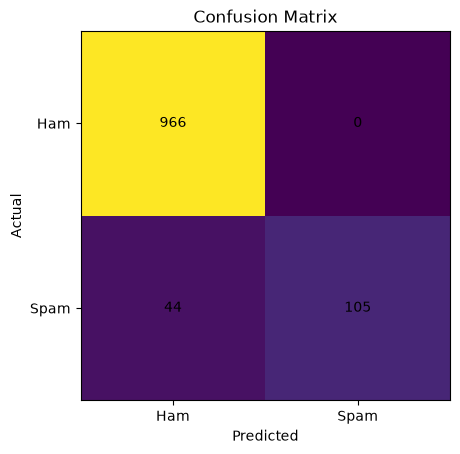

In [66]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")
plt.show()

The model correctly classified 966 ham messages and 105 spam messages. It incorrectly classified 44 spam messages as ham. This explains why the spam recall is approximately 0.70.

# 10. Testing Custom Messages:
The trained model can also be used to classify new SMS messages that were not part of the original dataset.

In [67]:
my_messages = [
    "Congratulations! You have won a free iPhone. Claim now!",
    "Hey, are we meeting at 5 today?",
    "URGENT! You have won 10000 dollars. Call now to claim your prize!",
    "Can you send me the notes from today's class?"
]
my_messages_tfidf = tfidf.transform(my_messages)
my_predictions = model.predict(my_messages_tfidf)
print(my_predictions)
for message, prediction in zip(my_messages, my_predictions):
    label = "SPAM" if prediction == 1 else "HAM"
    print(f"{label}: {message}")

[1 0 1 0]
SPAM: Congratulations! You have won a free iPhone. Claim now!
HAM: Hey, are we meeting at 5 today?
SPAM: URGENT! You have won 10000 dollars. Call now to claim your prize!
HAM: Can you send me the notes from today's class?


# 11. Conclusion:
This project demonstrates a basic machine learning pipeline for text classification.

TF-IDF was used to convert SMS messages into numerical features, and Multinomial Naive Bayes was used to classify messages as spam or ham.

The model achieved approximately 96% accuracy on the test set. However, the spam recall was 0.70, meaning that some spam messages were not detected. This shows why evaluating a classification model using multiple metrics is important rather than relying only on accuracy.

# What I learned:

- How to prepare a text dataset for machine learning
- Train-test splitting
- TF-IDF vectorization
- Multinomial Naive Bayes
- Classification metrics
- Confusion matrices
- Evaluating model limitations